# フェーズ1：擬似データ生成と確認（小売・サービス業 ポイントシステム）

来店予測のための擬似データ（1店舗・日次・2年分）を生成し、**狙った傾向が正しく埋め込まれているか** を可視化して確認します。

このフェーズの目的:
- フェーズ2（来店予測モデル）の土台となるデータを用意する
- 「曜日・季節・祝日・給料日・天候・人流・SNS先行・販促」が来店客数に現れているかを目視・数値で確認する

> ここで傾向が確認できれば、フェーズ2でモデルがそれを学習・再現できるかを検証できます。

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd() / "src"))
from retail_synthetic_data import generate_retail_data

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP"]:
    if any(_f in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

print("セットアップ完了 / pandas", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


セットアップ完了 / pandas 3.0.3


## 1. データ生成と概要

1店舗・2年分（730日）の日次データを生成します。列は要件定義書の4データソース（CPSS購買・天候・人流・SNS）＋販促＋カレンダーに対応しています。

In [2]:
df = generate_retail_data(start="2024-01-01", days=730, seed=42)
print("期間:", df["date"].min().date(), "〜", df["date"].max().date(), "／", len(df), "日 ×", len(df.columns), "列")
df.head(10)

期間: 2024-01-01 〜 2025-12-30 ／ 730 日 × 21 列


,date,visitors,sales_amount,avg_spend,member_visitors,member_ratio,new_member_ratio,repeat_ratio,temp_max,temp_min,precipitation_mm,weather,foot_traffic,sns_mentions,sns_sentiment,point_multiplier,is_sale,coupon_sent,is_holiday,is_weekend,is_payday
0,2024-01-01,686,1820644,2654,402,0.586,0.064,0.936,11.0,1.2,0.0,cloudy,8403,218,0.517,1,0,0,1,0,0
1,2024-01-02,534,1427382,2673,337,0.631,0.092,0.908,8.9,0.5,0.0,sunny,6705,238,0.553,1,0,0,0,0,0
2,2024-01-03,535,1372810,2566,335,0.626,0.062,0.938,11.5,1.2,0.0,sunny,6902,221,0.610,1,0,0,0,0,0
3,2024-01-04,635,1581150,2490,396,0.624,0.060,0.940,11.8,0.1,0.0,cloudy,6629,299,0.556,1,0,0,0,0,0
4,2024-01-05,711,1903347,2677,462,0.650,0.055,0.945,7.4,0.7,0.0,cloudy,8862,463,0.671,5,0,0,0,0,0
5,2024-01-06,1161,3202038,2758,761,0.656,0.072,0.928,8.3,0.5,0.0,cloudy,10901,399,0.640,1,1,0,0,1,0
6,2024-01-07,937,2487735,2655,639,0.682,0.090,0.910,10.4,1.4,0.0,sunny,9578,263,0.541,1,1,0,0,1,0
7,2024-01-08,627,1601985,2555,368,0.587,0.039,0.961,9.7,1.4,0.0,sunny,7640,160,0.534,1,0,0,1,0,0
8,2024-01-09,536,1272464,2374,344,0.642,0.038,0.962,10.1,-2.3,0.0,cloudy,5746,283,0.322,1,0,0,0,0,0
9,2024-01-10,615,1578705,2567,359,0.584,0.037,0.963,8.8,-3.2,0.0,sunny,6710,182,0.524,10,0,1,0,0,0


In [3]:
df.describe().round(2)

,date,visitors,sales_amount,avg_spend,member_visitors,member_ratio,new_member_ratio,repeat_ratio,temp_max,temp_min,precipitation_mm,foot_traffic,sns_mentions,sns_sentiment,point_multiplier,is_sale,coupon_sent,is_holiday,is_weekend,is_payday
count,730,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.00,730.0,730.00,730.00,730.00,730.00
mean,2024-12-30 12:00:00,914.03,2378309.08,2573.92,573.34,0.63,0.05,0.95,20.94,11.03,4.66,10781.37,348.14,0.53,1.69,0.1,0.08,0.05,0.28,0.18
min,2024-01-01 00:00:00,348.00,867564.00,2110.00,225.00,0.53,0.02,0.89,6.60,-3.20,0.00,4476.00,115.00,0.14,1.00,0.0,0.00,0.00,0.00,0.00
25%,2024-07-01 06:00:00,692.00,1719106.50,2448.25,431.75,0.60,0.04,0.94,13.20,3.32,0.00,8409.50,263.00,0.46,1.00,0.0,0.00,0.00,0.00,0.00
50%,2024-12-30 12:00:00,865.50,2177265.50,2545.00,538.00,0.62,0.05,0.95,20.95,11.15,0.00,10293.50,327.00,0.53,1.00,0.0,0.00,0.00,0.00,0.00
75%,2025-06-30 18:00:00,1066.75,2763332.00,2668.50,675.75,0.65,0.06,0.96,28.50,18.40,4.78,12684.50,412.00,0.60,1.00,0.0,0.00,0.00,1.00,0.00
max,2025-12-30 00:00:00,2211.00,7064145.00,3317.00,1376.00,0.74,0.11,0.98,34.80,24.90,63.30,24012.00,918.00,0.91,10.00,1.0,1.00,1.00,1.00,1.00
std,NaN,300.82,902374.90,179.63,194.23,0.04,0.01,0.01,7.91,7.85,9.61,3312.52,121.61,0.11,1.94,0.3,0.27,0.23,0.45,0.38


## 2. 来店客数の推移（全体像）

2年分の来店客数の動きです。週次の周期、季節のうねり、年末のピークが見て取れます。

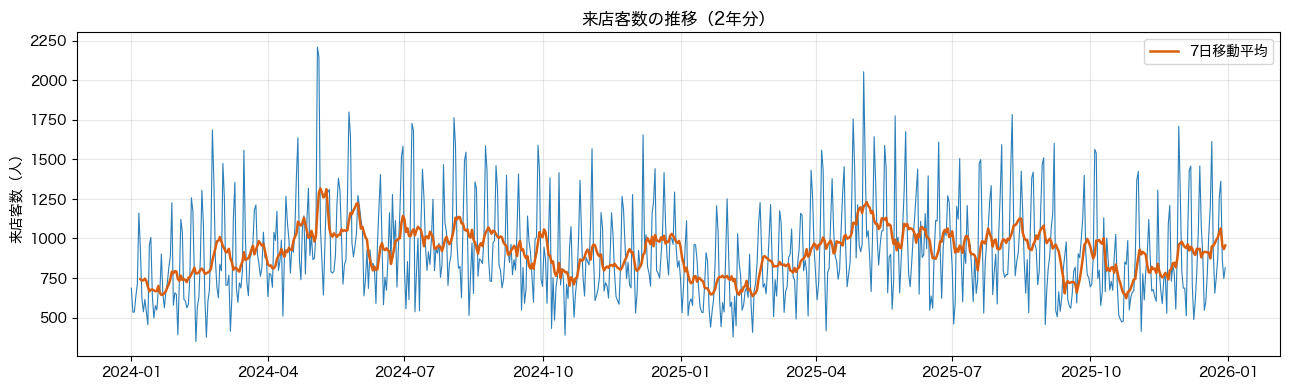

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["date"], df["visitors"], lw=0.8, color="#2c7fb8")
ax.plot(df["date"], df["visitors"].rolling(7).mean(), lw=1.8, color="#d95f0e", label="7日移動平均")
ax.set_title("来店客数の推移（2年分）")
ax.set_ylabel("来店客数（人）")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 埋め込んだ傾向の確認

「曜日・月（季節）・天候・販促」が来店客数にどう効いているかを集計して確認します。
狙い通りなら、週末・年末・特売日・ポイント◯倍デーで増え、雨で減るはずです。

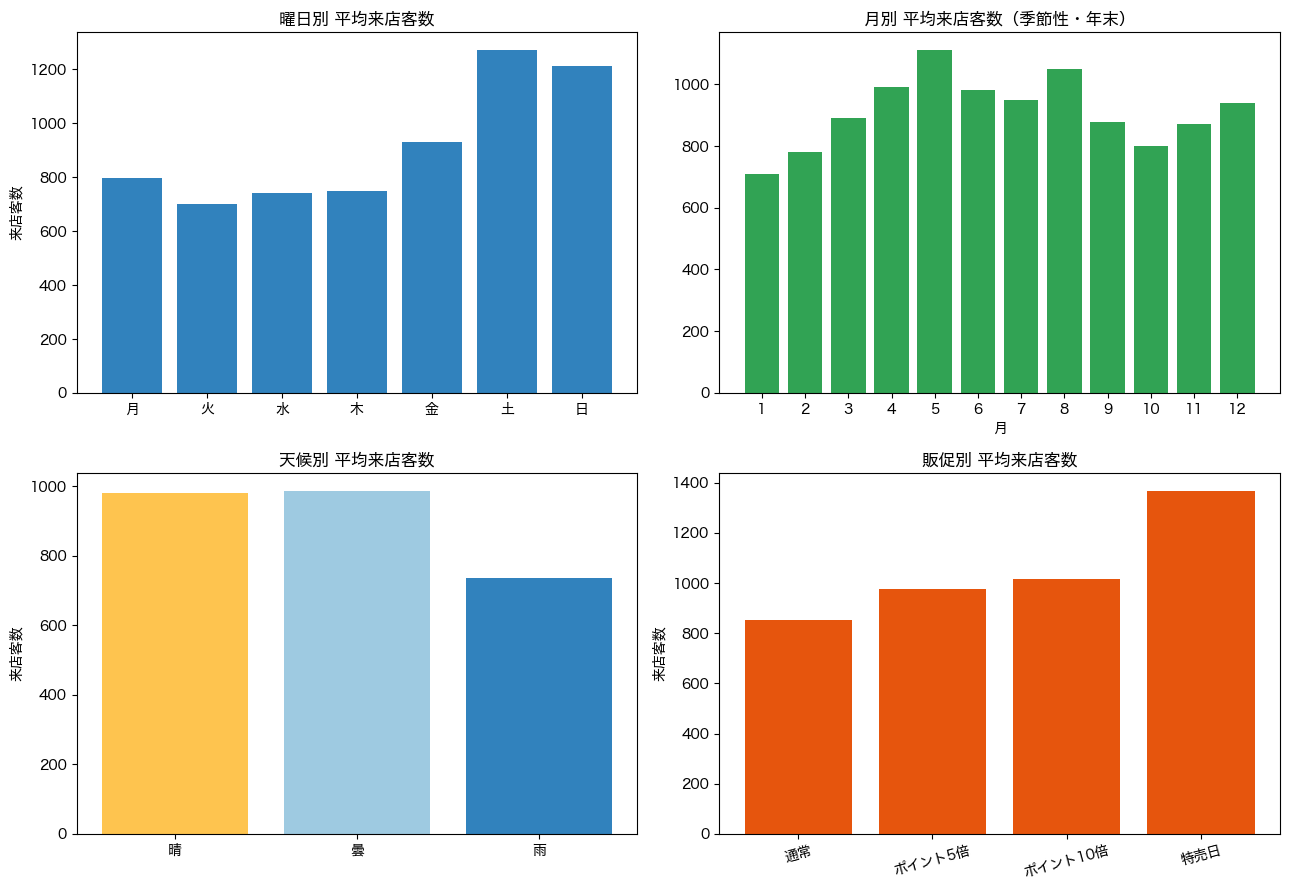

In [5]:
d = df.copy()
d["dow"] = d["date"].dt.dayofweek
d["month"] = d["date"].dt.month
dow_labels = ["月", "火", "水", "木", "金", "土", "日"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 曜日別
ax = axes[0, 0]
g = d.groupby("dow")["visitors"].mean()
ax.bar([dow_labels[i] for i in g.index], g.values, color="#3182bd")
ax.set_title("曜日別 平均来店客数")
ax.set_ylabel("来店客数")

# 月別（季節性）
ax = axes[0, 1]
g = d.groupby("month")["visitors"].mean()
ax.bar(g.index, g.values, color="#31a354")
ax.set_title("月別 平均来店客数（季節性・年末）")
ax.set_xlabel("月"); ax.set_xticks(range(1, 13))

# 天候別
ax = axes[1, 0]
order = ["sunny", "cloudy", "rain"]
g = d.groupby("weather")["visitors"].mean().reindex(order)
ax.bar(["晴", "曇", "雨"], g.values, color=["#fec44f", "#9ecae1", "#3182bd"])
ax.set_title("天候別 平均来店客数")
ax.set_ylabel("来店客数")

# 販促別
ax = axes[1, 1]
cats = {
    "通常": d[(d.is_sale == 0) & (d.point_multiplier == 1)]["visitors"].mean(),
    "ポイント5倍": d[d.point_multiplier == 5]["visitors"].mean(),
    "ポイント10倍": d[d.point_multiplier == 10]["visitors"].mean(),
    "特売日": d[d.is_sale == 1]["visitors"].mean(),
}
ax.bar(list(cats.keys()), list(cats.values()), color="#e6550d")
ax.set_title("販促別 平均来店客数")
ax.set_ylabel("来店客数")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 4. 人流・SNS と来店の関係

- **人流**：当日の人流が多い日は来店も多い（正の相関）
- **SNS**：前日のSNS言及数が翌日の来店の先行指標になる（リーク対策で「前日まで」を使う設計）

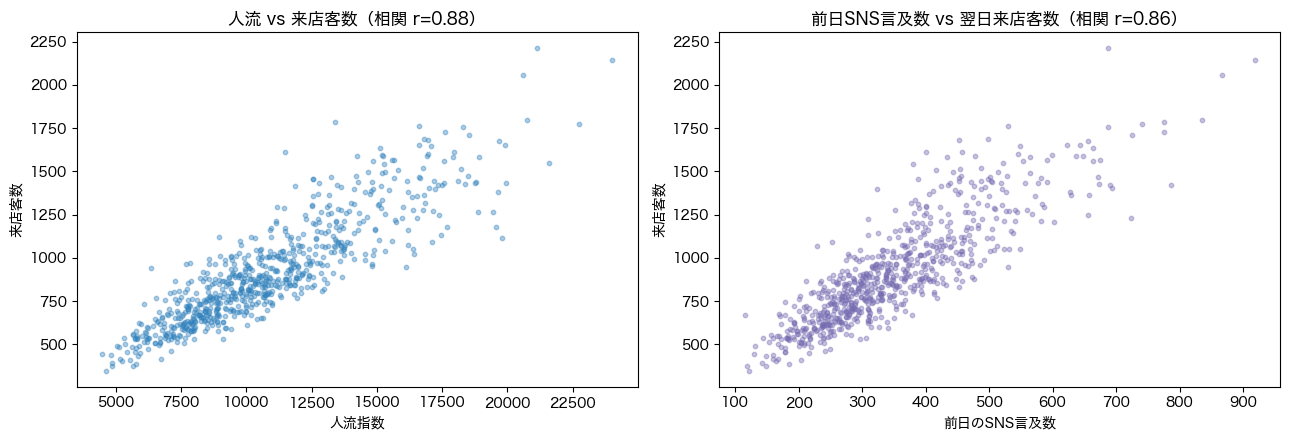

人流と来店の相関: 0.884
前日SNSと翌日来店の相関: 0.864


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 人流 vs 来店
ax = axes[0]
ax.scatter(df["foot_traffic"], df["visitors"], s=10, alpha=0.4, color="#3182bd")
r_foot = df["foot_traffic"].corr(df["visitors"])
ax.set_title(f"人流 vs 来店客数（相関 r={r_foot:.2f}）")
ax.set_xlabel("人流指数"); ax.set_ylabel("来店客数")

# 前日SNS vs 翌日来店
ax = axes[1]
sns_lag1 = df["sns_mentions"].shift(1)
ax.scatter(sns_lag1, df["visitors"], s=10, alpha=0.4, color="#756bb1")
r_sns = sns_lag1.corr(df["visitors"])
ax.set_title(f"前日SNS言及数 vs 翌日来店客数（相関 r={r_sns:.2f}）")
ax.set_xlabel("前日のSNS言及数"); ax.set_ylabel("来店客数")

plt.tight_layout()
plt.show()
print(f"人流と来店の相関: {r_foot:.3f}")
print(f"前日SNSと翌日来店の相関: {r_sns:.3f}")

## 5. 数値サマリー（傾向の定量確認）

各要因が来店客数を何倍にしているかを数値で確認します。

In [7]:
base = df[(df.is_sale == 0) & (df.point_multiplier == 1) & (df.is_weekend == 0) & (df.is_holiday == 0)]["visitors"].mean()

rows = [
    ("基準（平日・販促なし）", base, 1.0),
    ("週末", df[df.is_weekend == 1]["visitors"].mean(), None),
    ("祝日", df[df.is_holiday == 1]["visitors"].mean(), None),
    ("給料日前後", df[df.is_payday == 1]["visitors"].mean(), None),
    ("特売日", df[df.is_sale == 1]["visitors"].mean(), None),
    ("ポイント5倍", df[df.point_multiplier == 5]["visitors"].mean(), None),
    ("ポイント10倍", df[df.point_multiplier == 10]["visitors"].mean(), None),
    ("雨の日", df[df.weather == "rain"]["visitors"].mean(), None),
    ("晴の日", df[df.weather == "sunny"]["visitors"].mean(), None),
]
summary = pd.DataFrame(
    [(name, round(v), round(v / base, 2)) for name, v, _ in rows],
    columns=["条件", "平均来店客数", "基準比"],
)
summary

,条件,平均来店客数,基準比
0,基準（平日・販促なし）,763,1.00
1,週末,1243,1.63
2,祝日,1073,1.41
3,給料日前後,1003,1.32
4,特売日,1368,1.79
5,ポイント5倍,975,1.28
6,ポイント10倍,1017,1.33
7,雨の日,735,0.96
8,晴の日,979,1.28


In [8]:
# CSV保存（フェーズ2でそのまま読み込めるようにする）
out = Path("data/retail_synthetic.csv")
out.parent.mkdir(exist_ok=True)
df.to_csv(out, index=False, encoding="utf-8-sig")
print("保存しました:", out, "/", len(df), "行")

保存しました: data/retail_synthetic.csv / 730 行


## まとめ

- 1店舗・2年分の擬似データに、来店を動かす現実的な関係（曜日・季節・祝日・給料日・天候・人流・SNS先行・販促）を埋め込んで生成した
- 可視化・数値サマリーで、狙った傾向がデータに現れていることを確認した
- データは `data/retail_synthetic.csv` に保存済み

### 次フェーズ（フェーズ2）
このデータを使い、**来店予測モデル** を構築する：
1. 予測時点で入手可能な情報のみで特徴量を作成（天候は予報値、SNSは前日まで、来店はラグ）
2. 勾配ブースティングで学習し、ベースライン（曜日平均・移動平均・前年同日）と精度比較
3. 特徴量重要度で「何が来店を動かすか」を解釈
4. 続いて来店 → 売上（来店×客単価）へ接続